# Lung Cancer Survival – Random Forest
Target: `survived` (0 = no, 1 = yes)

## 1. Upload & unzip the dataset

In [8]:
from google.colab import files
uploaded = files.upload()   # choose lung_cancer_processed.zip
!unzip -o lung_cancer_processed.zip

Saving lung_cancer_processed.zip to lung_cancer_processed (1).zip
Archive:  lung_cancer_processed.zip
  inflating: lung_cancer_processed.csv  


## 2. Load data

In [9]:
import pandas as pd
df = pd.read_csv('lung_cancer_processed.csv')
print(df.shape)
print(df['survived'].value_counts(normalize=True))
df.head()

(886105, 22)
survived
0    0.779794
1    0.220206
Name: proportion, dtype: float64


,age,gender,country,cancer_stage,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,...,treatment_duration_days,diagnosis_year,smoking_Current Smoker,smoking_Former Smoker,smoking_Never Smoked,smoking_Passive Smoker,treatment_Chemotherapy,treatment_Combined,treatment_Radiation,treatment_Surgery
0,0.918122,0,26,1,1,-0.130726,-0.797375,0,0,1,...,0.466017,2016,0,0,0,1,1,0,0,0
1,-0.511199,1,19,3,1,1.279336,1.067513,1,1,0,...,-0.244589,2023,0,0,0,1,0,0,0,1
2,1.020216,1,12,3,1,1.613927,0.791233,1,1,0,...,-0.632192,2023,0,1,0,0,0,1,0,0
3,-0.409104,1,1,1,0,1.494430,0.169604,1,1,0,...,-0.108210,2016,0,0,0,1,1,0,0,0
4,-1.838425,0,17,1,0,-1.289845,-1.280865,0,0,0,...,-0.373790,2023,0,0,0,1,0,1,0,0


## 3. Train / test split (stratified)

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(708884, 21) (177221, 21)


## 4. Train Random Forest
`class_weight='balanced'` compensates for the ~22% positive class. Depth/leaf limits keep training fast on ~700k rows.

In [11]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1)

t = time.time()
rf.fit(X_train, y_train)
print(f'Training time: {time.time()-t:.1f}s')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  4.4min


Training time: 265.5s


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  4.4min finished


## 5. Evaluate

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.2s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    8.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    8.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.5s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    6.8s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    7.0s finished


Accuracy: 0.762003374317942
ROC-AUC : 0.4990328812623852
              precision    recall  f1-score   support

           0       0.78      0.97      0.86    138196
           1       0.21      0.03      0.05     39025

    accuracy                           0.76    177221
   macro avg       0.50      0.50      0.46    177221
weighted avg       0.65      0.76      0.69    177221



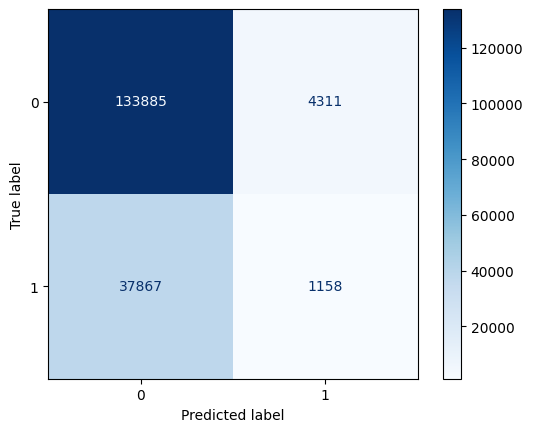

In [12]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC :', roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(cmap='Blues')
plt.show()

## 6. Feature importance

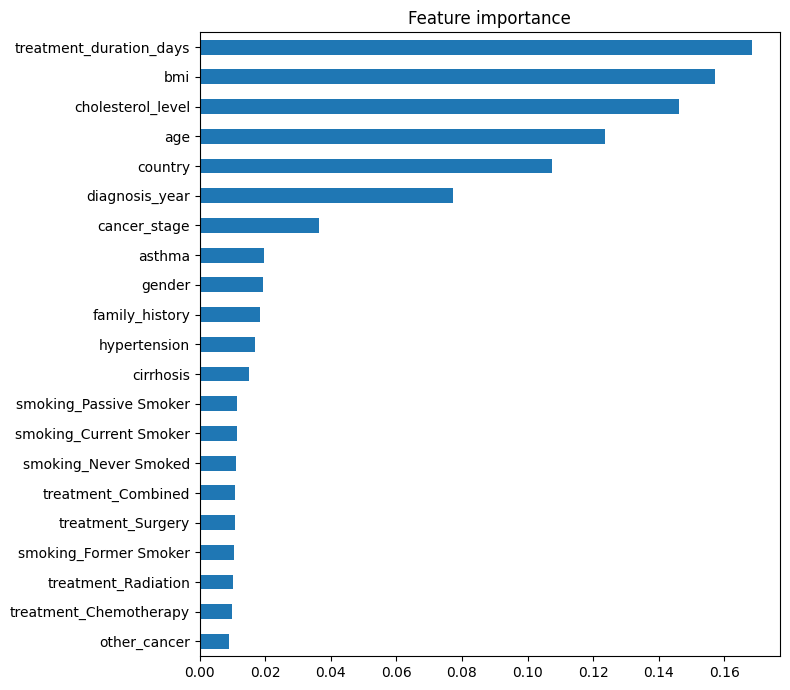

In [13]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', figsize=(8, 7), title='Feature importance')
plt.tight_layout(); plt.show()

## 7. Save the model (optional)

In [14]:
import joblib
joblib.dump(rf, 'rf_lung_cancer.joblib', compress=3)
files.download('rf_lung_cancer.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>